# 텍스트 빈도수 시각화 : 단어 빈도 그래프, 워드클라우드
1. 데이터 수집(로딩)
1. 텍스트 전처리
1. 빈도수 계산
1. 단어 빈도 그래프 시각화
1. 워드클라우드 시각화

## 1. 데이터 수집(로딩)

In [2]:
# 실습 문서 : 대한민국 헌법
from konlpy.corpus import kolaw
input_filename = 'constitution.txt'
const_doc = kolaw.open(input_filename).read()

#가져온 데이터 확인 (타입, 길이, 일부 데이터)
type(const_doc), len(const_doc), const_doc[:50]

(str, 18884, '대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임')

## 2. 텍스트 전처리
* 한글 : 품사 태깅 -> 필요 품사 단어만 사용 -> 불용어 삭제

In [3]:
from konlpy.tag import Okt
t = Okt()

# 명사만 추출
nouns = t.nouns(const_doc)

# 토큰 수
print(f'토큰 수: {len(nouns):,}')

# 토큰 일부 확인
nouns[:10]

토큰 수: 3,882


['대한민국', '헌법', '유구', '역사', '전통', '우리', '국민', '운동', '건립', '대한민국']

In [4]:
# 명사(일반 명사, 고유 명사), 동사, 형용사 단어 추출
my_tags = ['Noun', 'Verb', 'Adjective']

# 불용어 삭제 : 의미없는데 고빈도로 나오는 단어 추가
my_stopwords = ['제', '하는', '때']

tokens = [word for word, tag in t.pos(const_doc) if tag in my_tags and word not in my_stopwords and len(word) > 1]

# 토큰 수
print(f'토큰 수: {len(tokens):,}')

# 토큰 일부 확인
tokens[:10]

토큰 수: 3,955


['대한민국', '헌법', '유구', '역사', '전통', '빛나는', '우리', '국민', '운동', '건립']

In [5]:
# 불용어 삭제 : 의미없는데 고빈도로 나오는 단어 추가
my_stopwords = ['제', '하는', '때']

# 토큰 수


# 토큰 일부 확인


## 3.  빈도수 계산

In [6]:
# Counter 객체 생성
from collections import Counter
const_counter = Counter(tokens)

# 단어 수
print(len(const_counter))

# Counter 객체 내 (단어, 빈도수) 확인
list(const_counter.items())[:10]

1005


[('대한민국', 11),
 ('헌법', 53),
 ('유구', 1),
 ('역사', 1),
 ('전통', 1),
 ('빛나는', 1),
 ('우리', 3),
 ('국민', 61),
 ('운동', 2),
 ('건립', 1)]

In [7]:
# 빈도수 상위 단어의 (단어, 빈도수) 튜플 리스트 추출
const_counter.most_common(50)

[('한다', 155),
 ('법률', 127),
 ('대통령', 83),
 ('국가', 73),
 ('국회', 68),
 ('의하여', 66),
 ('국민', 61),
 ('하여', 61),
 ('있다', 57),
 ('헌법', 53),
 ('모든', 37),
 ('하며', 32),
 ('하여야', 31),
 ('아니', 30),
 ('기타', 26),
 ('가진다', 25),
 ('사항', 23),
 ('권리', 21),
 ('된다', 21),
 ('필요한', 21),
 ('없다', 21),
 ('의원', 21),
 ('자유', 20),
 ('정부', 20),
 ('선거', 20),
 ('임명', 20),
 ('되지', 19),
 ('직무', 19),
 ('국무총리', 19),
 ('경제', 18),
 ('의무', 18),
 ('조직', 18),
 ('국회의원', 18),
 ('임기', 18),
 ('의결', 17),
 ('공무원', 17),
 ('경우', 17),
 ('이상', 17),
 ('국무위원', 17),
 ('대법원', 17),
 ('하기', 16),
 ('범위', 16),
 ('이를', 15),
 ('받지', 15),
 ('법관', 15),
 ('보호', 14),
 ('정책', 14),
 ('정당', 14),
 ('헌법재판소', 14),
 ('재적', 14)]

## 4. 단어 빈도 그래프 시각화
1. 데이터 준비
2. 그래프 정보 추가
3. 막대 그래프 생성
4. 그래프 출력 (화면, 파일)

In [ ]:
# 데이터 준비 : 빈도수 상위 20개의 단어만 추출
# x 데이터 : word, y 데이터 : count
x = [word for word, count in const_counter.most_common(20)]
y = [count for word, count in const_counter.most_common(20)]
print(x[:10])
print(y[:10])

['한다', '법률', '대통령', '국가', '국회', '의하여', '국민', '하여', '있다', '헌법']
[155, 127, 83, 73, 68, 66, 61, 61, 57, 53]


In [32]:
# matplotlib 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

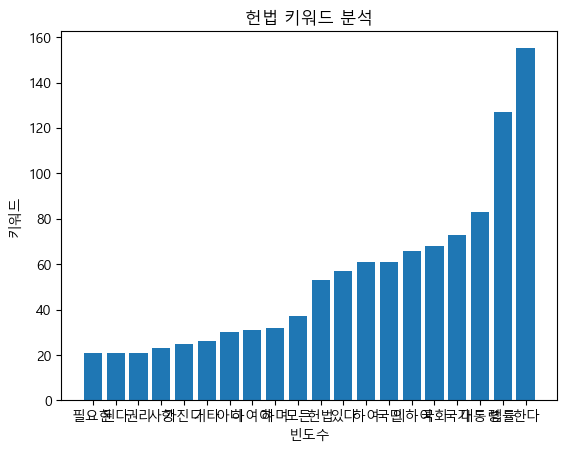

In [33]:
import matplotlib.pyplot as plt

# 수평 막대그래프
plt.bar(x[::-1], y[::-1])

# 그래프 정보 추가 
plt.title('헌법 키워드 분석')
plt.xlabel('빈도수')
plt.ylabel('키워드')

# 화면에 출력
plt.show()

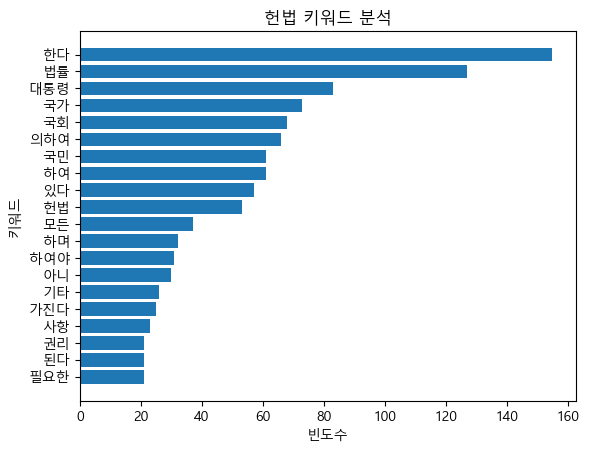

In [34]:
# 그래프 저장 : 그래프 생성 후 바로 savefig 사용

# 수평 막대그래프
plt.barh(x[::-1], y[::-1])

# 그래프 정보 추가
plt.title('헌법 키워드 분석')
plt.xlabel('빈도수')
plt.ylabel('키워드')

outputfile = input_filename.replace('.txt', '_bargraph.png')
plt.savefig(outputfile)

### 03-5. 워드 클라우드 시각화

* conda 환경에서 wordcloud 설치 (conda install wordcloud)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 path 지정
font_path = "c:/Windows/fonts/malgun.ttf"

# WordCloud 객체 생성
const_wc = WordCloud(font_path=font_path,
                     background_color="ivory"
                    )

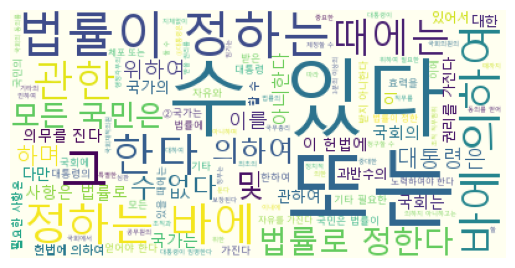

In [24]:
# 전체 텍스트로 워드클라우드 시각화
conwc = const_wc.generate(const_doc)

plt.imshow(const_wc)
plt.axis('off')
plt.show()

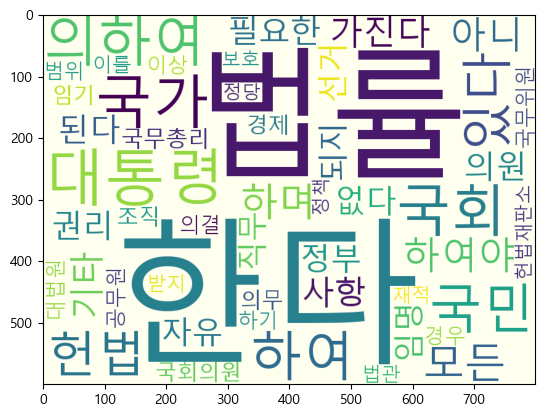

In [ ]:
# 빈도 데이터로 워드클라우드 시각화
const_wc = WordCloud(
                    font_path=font_path,
                    width=800,
                    height=600,
                    max_words=50,
                    background_color="ivory"
                    )
const_wc = const_wc.generate_from_frequencies(const_counter)
plt.imshow(const_wc)

In [28]:
# wordcloud 이미지 저장
const_wc.to_file(input_filename.replace('.txt', '_wordcloud.png'))